In [717]:
import numpy as np

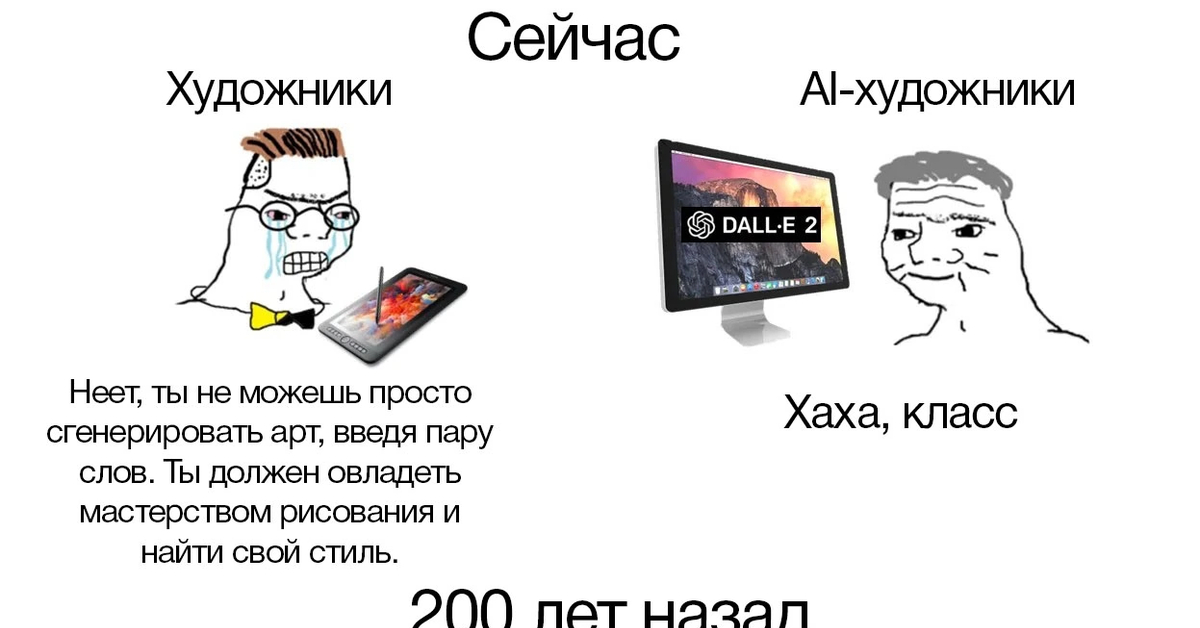

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [718]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [719]:

class Sequential(Module):
    """
         This class implements a container, which processes `input` data sequentially.

         `input` is processed by each module (layer) in self.modules consecutively.
         The resulting array is called `output`.
    """
    

    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Adds a module to the container.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        """
        Basic workflow of FORWARD PASS:

            y_0    = module[0].forward(input)
            y_1    = module[1].forward(y_0)
            ...
            output = module[n-1].forward(y_{n-2})


        Just write a little loop.
        """
        current = input
        for module in self.modules:
            current = module.forward(current)
        self.output = current
        return self.output

    def backward(self, input, gradOutput):
        """
        Workflow of BACKWARD PASS:

            g_{n-1} = module[n-1].backward(y_{n-2}, gradOutput)
            g_{n-2} = module[n-2].backward(y_{n-3}, g_{n-1})
            ...
            g_1 = module[1].backward(y_0, g_2)
            gradInput = module[0].backward(input, g_1)


        !!!

        To ech module you need to provide the input, module saw while forward pass,
        it is used while computing gradients.
        Make sure that the input for `i-th` layer the output of `module[i]` (just the same input as in forward pass)
        and NOT `input` to this Sequential module.

        !!!

        """
        current_grad = gradOutput

        for i in range(len(self.modules) - 1, -1, -1):
            if i == 0:
                current_input = input
            else:
                current_input = self.modules[i - 1].output

            current_grad = self.modules[i].backward(current_input, current_grad)

        self.gradInput = current_grad
        return self.gradInput


    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        """
        Should gather all parameters in a list.
        """
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        """
        Should gather all gradients w.r.t parameters in a list.
        """
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self,x):
        return self.modules.__getitem__(x)

    def train(self):
        """
        Propagates training parameter through all modules
        """
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        """
        Propagates training parameter through all modules
        """
        self.training = False
        for module in self.modules:
            module.evaluate()


# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [720]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # This is a nice initialization
        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradW += gradOutput.T @ input
        self.gradb += gradOutput.sum(axis=0)
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [721]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))
        exp_x = np.exp(self.output)
        self.output = exp_x / np.sum(exp_x, axis=1, keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        s = self.output
        dot = np.sum(gradOutput * s, axis=1, keepdims=True)
        self.gradInput = s * (gradOutput - dot)
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [722]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))
        log_sum_exp = np.log(np.sum(np.exp(self.output), axis=1, keepdims=True))
        self.output = self.output - log_sum_exp
        return self.output


    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        softmax = np.exp(self.output)
        self.gradInput = gradOutput - softmax * np.sum(gradOutput, axis=1, keepdims=True)
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [723]:
class BatchNormalization(Module):
    EPS = 1e-3
    def __init__(self, alpha = 0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        if self.training:
            batch_mean = np.mean(input, axis=0)
            batch_var = np.var(input, axis=0)

            if self.moving_mean is None:
                self.moving_mean = batch_mean.copy()
            else:
                self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * batch_mean

            if self.moving_variance is None:
                self.moving_variance = batch_var.copy()
            else:
                self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * batch_var

            self.batch_mean = batch_mean
            self.batch_var = batch_var
            self.centered = input - batch_mean
            self.std_inv = 1.0 / np.sqrt(batch_var + self.EPS)

            self.output = self.centered * self.std_inv
        else:
            self.output = (input - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)

        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.training:
            n = input.shape[0]

            x_mu = self.centered
            std_inv = self.std_inv
            x_hat = x_mu * std_inv

            self.gradInput = (1.0 / n) * std_inv * (
                n * gradOutput
                - np.sum(gradOutput, axis=0)
                - x_hat * np.sum(gradOutput * x_hat, axis=0)
            )
        else:
            self.gradInput = gradOutput / np.sqrt(self.moving_variance + self.EPS)

        return self.gradInput

    def __repr__(self):
        return "BatchNormalization"

In [724]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = gamma * x + beta
       where gamma, beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1. / np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def _reshape_params(self, input):
        shape = [1] * input.ndim
        shape[1] = -1
        return self.gamma.reshape(shape), self.beta.reshape(shape)

    def updateOutput(self, input):
        gamma, beta = self._reshape_params(input)
        self.output = input * gamma + beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        gamma, _ = self._reshape_params(input)
        self.gradInput = gradOutput * gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        if input.ndim == 2:
            axes = (0,)
        else:
            axes = (0,) + tuple(range(2, input.ndim))

        self.gradGamma += np.sum(input * gradOutput, axis=axes)
        self.gradBeta += np.sum(gradOutput, axis=axes)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [725]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        if self.training:
            self.mask = (np.random.rand(*input.shape) >= self.p).astype(input.dtype)
            self.output = input * self.mask / (1 - self.p)
        else:
            self.output = input.copy()
        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.training:
            self.gradInput = gradOutput * self.mask / (1 - self.p)
        else:
            self.gradInput = gradOutput.copy()
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [726]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.padding_mode = padding_mode

        if isinstance(kernel_size, int):
            self.kh, self.kw = kernel_size, kernel_size
        else:
            self.kh, self.kw = kernel_size

        if isinstance(stride, int):
            self.sh, self.sw = stride, stride
        else:
            self.sh, self.sw = stride

        stdv = 1. / np.sqrt(in_channels * self.kh * self.kw)

        self.weight = np.random.uniform(
            -stdv, stdv,
            (out_channels, in_channels, self.kh, self.kw)
        )
        self.gradWeight = np.zeros_like(self.weight)

        if bias:
            self.bias = np.random.uniform(-stdv, stdv, out_channels)
            self.gradBias = np.zeros_like(self.bias)
        else:
            self.bias = None
            self.gradBias = None

    def _get_padding(self, H, W):
        if isinstance(self.padding, str):
            if self.padding == 'valid':
                return 0, 0, 0, 0
            elif self.padding == 'same':
                out_h = int(np.ceil(H / self.sh))
                out_w = int(np.ceil(W / self.sw))

                pad_h_total = max((out_h - 1) * self.sh + self.kh - H, 0)
                pad_w_total = max((out_w - 1) * self.sw + self.kw - W, 0)

                pad_top = pad_h_total // 2
                pad_bottom = pad_h_total - pad_top
                pad_left = pad_w_total // 2
                pad_right = pad_w_total - pad_left
                return pad_top, pad_bottom, pad_left, pad_right
            else:
                raise ValueError("Unsupported padding value")
        elif isinstance(self.padding, int):
            return self.padding, self.padding, self.padding, self.padding
        else:
            ph, pw = self.padding
            return ph, ph, pw, pw

    def _pad_input(self, input, pad_top, pad_bottom, pad_left, pad_right):
        if pad_top == 0 and pad_bottom == 0 and pad_left == 0 and pad_right == 0:
            return input

        if self.padding_mode == 'zeros':
            mode = 'constant'
            kwargs = {'constant_values': 0}
        elif self.padding_mode == 'replicate':
            mode = 'edge'
            kwargs = {}
        elif self.padding_mode == 'reflect':
            mode = 'reflect'
            kwargs = {}
        else:
            raise ValueError("Unsupported padding_mode")

        return np.pad(
            input,
            ((0, 0), (0, 0), (pad_top, pad_bottom), (pad_left, pad_right)),
            mode=mode,
            **kwargs
        )
    
    def _reflect_indices(self, idxs, size):
        if size == 1:
            return np.zeros_like(idxs)

        period = 2 * size - 2
        idxs = np.abs(idxs) % period
        idxs = np.where(idxs >= size, period - idxs, idxs)
        return idxs

    def _unpad_grad_input(self, grad_input_padded, H, W):
        if self.padding_mode == 'zeros':
            h_start = self.pad_top
            h_end = grad_input_padded.shape[2] - self.pad_bottom if self.pad_bottom > 0 else grad_input_padded.shape[2]
            w_start = self.pad_left
            w_end = grad_input_padded.shape[3] - self.pad_right if self.pad_right > 0 else grad_input_padded.shape[3]
            return grad_input_padded[:, :, h_start:h_end, w_start:w_end]

        row_coords = np.arange(-self.pad_top, H + self.pad_bottom)
        col_coords = np.arange(-self.pad_left, W + self.pad_right)

        if self.padding_mode == 'replicate':
            row_idx = np.clip(row_coords, 0, H - 1)
            col_idx = np.clip(col_coords, 0, W - 1)
        elif self.padding_mode == 'reflect':
            row_idx = self._reflect_indices(row_coords, H)
            col_idx = self._reflect_indices(col_coords, W)
        else:
            raise ValueError("Unsupported padding_mode")

        grad_input = np.zeros(
            (grad_input_padded.shape[0], grad_input_padded.shape[1], H, W),
            dtype=grad_input_padded.dtype
        )

        for r, rr in enumerate(row_idx):
            for c, cc in enumerate(col_idx):
                grad_input[:, :, rr, cc] += grad_input_padded[:, :, r, c]

        return grad_input

    def updateOutput(self, input):
        N, C, H, W = input.shape
        assert C == self.in_channels

        self.pad_top, self.pad_bottom, self.pad_left, self.pad_right = self._get_padding(H, W)
        self.input_padded = self._pad_input(
            input, self.pad_top, self.pad_bottom, self.pad_left, self.pad_right
        )

        H_pad, W_pad = self.input_padded.shape[2], self.input_padded.shape[3]
        H_out = (H_pad - self.kh) // self.sh + 1
        W_out = (W_pad - self.kw) // self.sw + 1

        self.output = np.zeros((N, self.out_channels, H_out, W_out), dtype=input.dtype)

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * self.sh
                h_end = h_start + self.kh
                w_start = j * self.sw
                w_end = w_start + self.kw

                patch = self.input_padded[:, :, h_start:h_end, w_start:w_end]
                self.output[:, :, i, j] = np.tensordot(
                    patch, self.weight, axes=([1, 2, 3], [1, 2, 3])
                )

        if self.bias is not None:
            self.output += self.bias[None, :, None, None]

        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]

        grad_input_padded = np.zeros_like(self.input_padded)

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * self.sh
                h_end = h_start + self.kh
                w_start = j * self.sw
                w_end = w_start + self.kw

                grad_input_padded[:, :, h_start:h_end, w_start:w_end] += np.tensordot(
                    gradOutput[:, :, i, j], self.weight, axes=([1], [0])
                )

        self.gradInput = self._unpad_grad_input(grad_input_padded, H, W)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradWeight.fill(0)
        if self.bias is not None:
            self.gradBias.fill(0)

        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * self.sh
                h_end = h_start + self.kh
                w_start = j * self.sw
                w_end = w_start + self.kw

                patch = self.input_padded[:, :, h_start:h_end, w_start:w_end]
                self.gradWeight += np.tensordot(
                    gradOutput[:, :, i, j], patch, axes=([0], [0])
                )

        if self.bias is not None:
            self.gradBias += np.sum(gradOutput, axis=(0, 2, 3))

    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.bias is not None:
            self.gradBias.fill(0)

    def getParameters(self):
        if self.bias is not None:
            return [self.weight, self.bias]
        return [self.weight]

    def getGradParameters(self):
        if self.bias is not None:
            return [self.gradWeight, self.gradBias]
        return [self.gradWeight]

    def __repr__(self):
        return "Conv2d"

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [727]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        N, C, H, W = input.shape
        k = self.kernel_size
        s = self.stride
        p = self.padding

        if p > 0:
            self.input_padded = np.pad(
                input,
                ((0, 0), (0, 0), (p, p), (p, p)),
                mode='constant',
                constant_values=-np.inf
            )
        else:
            self.input_padded = input

        H_out = (self.input_padded.shape[2] - k) // s + 1
        W_out = (self.input_padded.shape[3] - k) // s + 1

        self.output = np.zeros((N, C, H_out, W_out))
        self.max_mask = np.zeros_like(self.input_padded, dtype=bool)

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * s
                h_end = h_start + k
                w_start = j * s
                w_end = w_start + k

                window = self.input_padded[:, :, h_start:h_end, w_start:w_end]
                max_vals = np.max(window, axis=(2, 3))
                self.output[:, :, i, j] = max_vals

                mask = (window == max_vals[:, :, None, None])
                self.max_mask[:, :, h_start:h_end, w_start:w_end] |= mask

        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        k = self.kernel_size
        s = self.stride
        p = self.padding

        grad_input_padded = np.zeros_like(self.input_padded)
        H_out = gradOutput.shape[2]
        W_out = gradOutput.shape[3]

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * s
                h_end = h_start + k
                w_start = j * s
                w_end = w_start + k

                window = self.input_padded[:, :, h_start:h_end, w_start:w_end]
                max_vals = np.max(window, axis=(2, 3))
                mask = (window == max_vals[:, :, None, None])

                grad = gradOutput[:, :, i, j][:, :, None, None]
                grad_input_padded[:, :, h_start:h_end, w_start:w_end] += grad * mask

        if p > 0:
            self.gradInput = grad_input_padded[:, :, p:-p, p:-p]
        else:
            self.gradInput = grad_input_padded

        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"

class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        N, C, H, W = input.shape
        k = self.kernel_size
        s = self.stride
        p = self.padding

        if p > 0:
            self.input_padded = np.pad(
                input,
                ((0, 0), (0, 0), (p, p), (p, p)),
                mode='constant',
                constant_values=0
            )
        else:
            self.input_padded = input

        H_out = (self.input_padded.shape[2] - k) // s + 1
        W_out = (self.input_padded.shape[3] - k) // s + 1

        self.output = np.zeros((N, C, H_out, W_out))

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * s
                h_end = h_start + k
                w_start = j * s
                w_end = w_start + k

                window = self.input_padded[:, :, h_start:h_end, w_start:w_end]
                self.output[:, :, i, j] = np.mean(window, axis=(2, 3))

        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        k = self.kernel_size
        s = self.stride
        p = self.padding

        if p > 0:
            grad_input_padded = np.zeros_like(self.input_padded)
        else:
            grad_input_padded = np.zeros_like(input)

        H_out = gradOutput.shape[2]
        W_out = gradOutput.shape[3]

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * s
                h_end = h_start + k
                w_start = j * s
                w_end = w_start + k

                grad = gradOutput[:, :, i, j][:, :, None, None] / (k * k)
                grad_input_padded[:, :, h_start:h_end, w_start:w_end] += grad

        if p > 0:
            self.gradInput = grad_input_padded[:, :, p:-p, p:-p]
        else:
            self.gradInput = grad_input_padded

        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"


#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [728]:
class Flatten(Module):
    def __init__(self, start_dim=0, end_dim=-1):
        super(Flatten, self).__init__()

        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        ndim = input.ndim

        start_dim = self.start_dim
        end_dim = self.end_dim

        if start_dim < 0:
            start_dim += ndim
        if end_dim < 0:
            end_dim += ndim

        shape = input.shape
        flat_dim = int(np.prod(shape[start_dim:end_dim + 1]))
        new_shape = shape[:start_dim] + (flat_dim,) + shape[end_dim + 1:]

        self.input_shape = input.shape
        self.output = input.reshape(new_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput.reshape(self.input_shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [729]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [730]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        self.output = np.where(input >= 0, input, self.slope * input)
        return self.output

    def updateGradInput(self, input, gradOutput):
        deriv = np.where(input >= 0, 1.0, self.slope)
        self.gradInput = gradOutput * deriv
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [731]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        self.output = np.where(input >= 0, input, self.alpha * (np.exp(input) - 1))
        return self.output

    def updateGradInput(self, input, gradOutput):
        deriv = np.where(input >= 0, 1.0, self.alpha * np.exp(input))
        self.gradInput = gradOutput * deriv
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [732]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        self.output = np.log1p(np.exp(-np.abs(input))) + np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        sigmoid = 1.0 / (1.0 + np.exp(-input))
        self.gradInput = gradOutput * sigmoid
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [733]:
from math import erf

class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        erf_vec = np.vectorize(erf)
        self.output = 0.5 * input * (1.0 + erf_vec(input / np.sqrt(2.0)))
        return self.output

    def updateGradInput(self, input, gradOutput):
        erf_vec = np.vectorize(erf)

        cdf = 0.5 * (1.0 + erf_vec(input / np.sqrt(2.0)))
        pdf = np.exp(-0.5 * input**2) / np.sqrt(2.0 * np.pi)

        deriv = cdf + input * pdf
        self.gradInput = gradOutput * deriv
        return self.gradInput

    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [734]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [735]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [736]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)
        
        self.output = -np.sum(target * np.log(input_clamp)) / input.shape[0]

        # Your code goes here. ################################################
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        self.gradInput = -(target / input_clamp) / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [737]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        # Your code goes here. ################################################
        self.output = -np.sum(target * input) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        # Your code goes here. ################################################
        self.gradInput = -target / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.
6. Свитч лося (метрики) и оптимайзера.

# 2 часть задания

#### Я за английский не особо шарю, так что объясняю на родном русском

## А-ля подготовка к творению волжебства
Начнём с того, что я сделаю аккуратный способ пройтись по всем параметрам модели и их градиентам

In [738]:
import numpy as np
import copy
import math
import matplotlib.pyplot as plt

In [739]:
def iter_parameters_and_grads(model):
    """
    эта штука проходит по всем параметрам модели и соответствующим градиентам
    У Sequential getParameters() и getGradParameters() возвращают вложенные списки,
    поэтому здесь мы аккуратно разворачиваем их
    """
    params_nested = model.getParameters()
    grads_nested = model.getGradParameters()

    for params_group, grads_group in zip(params_nested, grads_nested):
        if params_group is None or grads_group is None:
            continue

        for p, g in zip(params_group, grads_group):
            if p is None or g is None:
                continue
            yield p, g

### Обход параметров модели

так как модель реализована как контейнер из слоёв (Sequential), параметры и градиенты возвращаются не одним массивом, а вложенной структурой списков. Поэтому я добавил вспомогательную функцию iter_parameters_and_grads, которая проходит по всем параметрам модели и их градиентам в едином формате

это надо для того, чтобы оптимизатор мог обновлять параметры независимо от того, сколько слоёв в модели и какие именно слои содержат обучаемые веса

### оптимизаторы

In [740]:
class SGD:
    def __init__(self, model, lr=1e-2):
        self.model = model
        self.lr = lr

    def step(self):
        for p, g in iter_parameters_and_grads(self.model):
            p -= self.lr * g

    def zero_grad(self):
        self.model.zeroGradParameters()

    def state_dict(self):
        return {"lr": self.lr}

In [741]:
class Adam:
    def __init__(self, model, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.model = model
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        self.t = 0
        self.m = {}
        self.v = {}

    def step(self):
        self.t += 1

        for idx, (p, g) in enumerate(iter_parameters_and_grads(self.model)):
            if idx not in self.m:
                self.m[idx] = np.zeros_like(p)
                self.v[idx] = np.zeros_like(p)

            self.m[idx] = self.beta1 * self.m[idx] + (1 - self.beta1) * g
            self.v[idx] = self.beta2 * self.v[idx] + (1 - self.beta2) * (g ** 2)

            m_hat = self.m[idx] / (1 - self.beta1 ** self.t)
            v_hat = self.v[idx] / (1 - self.beta2 ** self.t)

            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        self.model.zeroGradParameters()

    def state_dict(self):
        return {
            "lr": self.lr,
            "beta1": self.beta1,
            "beta2": self.beta2,
            "eps": self.eps,
            "t": self.t
        }

для обучения моделей были реализованы два оптимизатора: SGD и Adam

### SGD
стохастический градиентный спуск обновляет параметры по правилу:

\[
\theta = \theta - \eta \cdot \nabla_\theta L
\]

где:
- \(\theta\) — параметры модели,
- \(\eta\) — learning rate,
- \(\nabla_\theta L\) — градиент функции потерь

это самый базовый и интерпретируемый оптимизатор (базовый мниимум)

### Adam
Adam использует:
- накопление первого момента градиента (аналог усреднённого направления),
- накопление второго момента (аналог усреднённого квадрата градиента),
- bias correction на ранних шагах обучения


### Scheduler и warmup

warmup

In [742]:
class WarmupScheduler:
    def __init__(self, optimizer, base_lr, warmup_epochs=5):
        self.optimizer = optimizer
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            new_lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.optimizer.lr = new_lr

StepLR

In [743]:
class StepLR:
    def __init__(self, optimizer, step_size=10, gamma=0.5):
        self.optimizer = optimizer
        self.step_size = step_size
        self.gamma = gamma

    def step(self, epoch=None, metric=None):
        if epoch is not None and epoch > 0 and epoch % self.step_size == 0:
            self.optimizer.lr *= self.gamma

ReduceLROnPlateau

In [744]:
class ReduceLROnPlateau:
    def __init__(self, optimizer, factor=0.5, patience=5, min_lr=1e-6):
        self.optimizer = optimizer
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr

        self.best = np.inf
        self.num_bad_epochs = 0

    def step(self, epoch=None, metric=None):
        if metric is None:
            return

        if metric < self.best:
            self.best = metric
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1

        if self.num_bad_epochs >= self.patience:
            new_lr = max(self.optimizer.lr * self.factor, self.min_lr)
            self.optimizer.lr = new_lr
            self.num_bad_epochs = 0

для улучшения обучения я добавил механизмы управления learning rate

### Warmup
на первых эпохах learning rate плавно увеличивается от маленького значения до базового. Это помогает сделать старт обучения более стабильным, особенно для моделей с BatchNorm и более глубоких архитектур

### StepLR
этот scheduler уменьшает learning rate через фиксированное число эпох. Подход простой и интерпретируемый

### ReduceLROnPlateau
этот scheduler уменьшает learning rate, если качество на валидации долго не улучшается. Такой подход особенно полезен, когда модель выходит на плато

### Early stopping и сохранение лучшей модели

In [745]:
class EarlyStopping:
    def __init__(self, patience=10, mode="min"):
        self.patience = patience
        self.mode = mode

        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return False

        improved = (score < self.best_score) if self.mode == "min" else (score > self.best_score)

        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

        return self.should_stop

In [746]:
def clone_parameters(model):
    """
    Сохраняем копию параметров лучшей модели.
    """
    snapshot = []
    for p, _ in iter_parameters_and_grads(model):
        snapshot.append(p.copy())
    return snapshot


def restore_parameters(model, snapshot):
    """
    Восстанавливаем параметры модели из сохранённого снапшота.
    """
    for (p, _), saved in zip(iter_parameters_and_grads(model), snapshot):
        p[...] = saved

## early stopping и сохранение лучшей модели

во время обучения модель может начать переобучаться: качество на train продолжает улучшаться, а на validation — перестаёт. Чтобы остановить обучение вовремя, был реализован механизм early stopping

также дополнительно сохраняются параметры лучшей модели на валидации Это позволяет:
- не использовать веса последней эпохи, если они хуже
- вернуть именно ту версию модели, которая показала лучший результат на validation

### метрики и свитч лосса / оптимайзера

метрики для регрессии

In [747]:
def mse_metric(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae_metric(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_metric(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

метрика для классификации

In [748]:
def accuracy_metric(y_true_labels, y_pred_logits):
    y_pred_labels = np.argmax(y_pred_logits, axis=1)
    return np.mean(y_true_labels == y_pred_labels)

свитч оптимизатора

In [749]:
def make_optimizer(name, model, lr=1e-3):
    name = name.lower()

    if name == "sgd":
        return SGD(model, lr=lr)
    elif name == "adam":
        return Adam(model, lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

## метрики и переключение конфигураций

для удобства экспериментов добавил:
- функции вычисления метрик
- возможность выбирать оптимизатор по имени
- единый интерфейс обучения

для мультирегрессии использую:
- MSE
- MAE
- R²

для классификации использую accuracy

## мини-батчи

In [750]:
def make_batches(X, y, batch_size=32, shuffle=True):
    n = X.shape[0]
    indices = np.arange(n)

    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

# общий цикл обучения

In [751]:
def train_one_epoch(model, optimizer, loss_fn, X, y, batch_size=32):
    model.train()
    optimizer.zero_grad()

    total_loss = 0.0
    n_batches = 0

    for x_batch, y_batch in make_batches(X, y, batch_size=batch_size, shuffle=True):
        output = model.forward(x_batch)
        loss = loss_fn.forward(output, y_batch)

        grad_loss = loss_fn.backward(output, y_batch)
        model.backward(x_batch, grad_loss)

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss
        n_batches += 1

    return total_loss / max(n_batches, 1)

In [752]:
def evaluate_model(model, loss_fn, X, y, batch_size=256):
    model.evaluate()

    total_loss = 0.0
    n_batches = 0
    preds = []
    targets = []

    for x_batch, y_batch in make_batches(X, y, batch_size=batch_size, shuffle=False):
        output = model.forward(x_batch)
        loss = loss_fn.forward(output, y_batch)

        total_loss += loss
        n_batches += 1

        preds.append(output.copy())
        targets.append(y_batch.copy())

    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)

    return total_loss / max(n_batches, 1), preds, targets

In [753]:
def fit(
    model,
    optimizer,
    loss_fn,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    batch_size=32,
    metric_fn=None,
    scheduler=None,
    warmup=None,
    early_stopping=None,
    verbose=True
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_metric": [],
        "val_metric": [],
        "lr": []
    }

    best_snapshot = None
    best_val_loss = np.inf

    for epoch in range(epochs):
        if warmup is not None:
            warmup.step(epoch)

        train_loss = train_one_epoch(model, optimizer, loss_fn, X_train, y_train, batch_size=batch_size)
        val_loss, val_preds, val_targets = evaluate_model(model, loss_fn, X_val, y_val, batch_size=batch_size)

        train_eval_loss, train_preds, train_targets = evaluate_model(model, loss_fn, X_train, y_train, batch_size=batch_size)

        if metric_fn is not None:
            train_metric = metric_fn(train_targets, train_preds)
            val_metric = metric_fn(val_targets, val_preds)
        else:
            train_metric = None
            val_metric = None

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_metric"].append(train_metric)
        history["val_metric"].append(val_metric)
        history["lr"].append(optimizer.lr)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_snapshot = clone_parameters(model)

        if scheduler is not None:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(metric=val_loss)
            else:
                scheduler.step(epoch=epoch)

        if verbose:
            if metric_fn is not None:
                print(
                    f"Epoch {epoch+1:03d} | "
                    f"lr={optimizer.lr:.6f} | "
                    f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | "
                    f"train_metric={train_metric:.6f} | val_metric={val_metric:.6f}"
                )
            else:
                print(
                    f"Epoch {epoch+1:03d} | "
                    f"lr={optimizer.lr:.6f} | "
                    f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f}"
                )

        if early_stopping is not None:
            stop = early_stopping.step(val_loss)
            if stop:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    if best_snapshot is not None:
        restore_parameters(model, best_snapshot)

    return history

## общий цикл обучения

ну тут всё очев, я реализовал единый цикл обучения fit, который поддерживает:
- обучение по эпохам
- валидацию после каждой эпохи
- подсчёт метрик
- scheduler
- warmup
- early stopping
- сохранение лучшей модели

## Рисунки (графики)

In [754]:
def plot_history(history, metric_name="metric"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(history["train_loss"], label="train_loss")
    axes[0].plot(history["val_loss"], label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    if history["train_metric"][0] is not None:
        axes[1].plot(history["train_metric"], label=f"train_{metric_name}")
        axes[1].plot(history["val_metric"], label=f"val_{metric_name}")
        axes[1].set_title(metric_name)
        axes[1].set_xlabel("Epoch")
        axes[1].legend()
    else:
        axes[1].axis("off")

    axes[2].plot(history["lr"], label="lr")
    axes[2].set_title("Learning rate")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

визуализация обучения

для анализа качества обучения у нас вот такие графики:
- loss на train и validation
- метрика на train и validation
- learning rate по эпохам

они позволяют увидеть: есть ли переобучение, помогает ли schedule, стабильно ли сходится модель и на какой эпохе достигается лучший результат

# Мультирегрессия на табличных данных


для этой задачи я выбрал небольшую табличную выборку Linnerud из sklearn, этот датасет удобен тем, что:
- он встроен в библиотеку и не требует отдельной загрузки;
- содержит несколько входных признаков;
- содержит сразу несколько целевых переменных;
- подходит для демонстрации работы полносвязной нейронной сети.

для решения задачи использую полносвязную нейронную сеть (FCNN), так как для табличных данных именно такой тип архитектуры является наиболее естественным базовым вариантом. также в модели использую:
- BatchNormalization для стабилизации обучения
- Dropout для борьбы с переобучением
- MSE в качестве функции потерь
- несколько функций активации для сравнения


In [755]:
from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [756]:
data = load_linnerud()

X = data.data.astype(np.float32)
y = data.target.astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("feature names:", data.feature_names)
print("target names:", data.target_names)

X shape: (20, 3)
y shape: (20, 3)
feature names: ['Chins', 'Situps', 'Jumps']
target names: ['Weight', 'Waist', 'Pulse']


## датасет

датасет Linnerud 
В нём:
вход X - числовые признаки
выход y  - несколько непрерывных целевых переменных

задача формулируется как предсказание вектора из нескольких чисел по входному вектору признаков

Ну а дальше начинается машинка

In [757]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)
print("test:", X_test.shape, y_test.shape)

train: (12, 3) (12, 3)
val: (4, 3) (4, 3)
test: (4, 3) (4, 3)


In [758]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train).astype(np.float32)
X_val = x_scaler.transform(X_val).astype(np.float32)
X_test = x_scaler.transform(X_test).astype(np.float32)

y_train = y_scaler.fit_transform(y_train).astype(np.float32)
y_val = y_scaler.transform(y_val).astype(np.float32)
y_test = y_scaler.transform(y_test).astype(np.float32)

### MSE-лосс для регрессии

In [759]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.mean((input - target) ** 2)
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput = 2.0 * (input - target) / input.size
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

### выбор активации

чтобы был красивый свитч активации

In [760]:
def make_activation(name):
    name = name.lower()

    if name == "relu":
        return ReLU()
    elif name == "leakyrelu":
        return LeakyReLU(0.1)
    elif name == "elu":
        return ELU(alpha=1.0)
    elif name == "softplus":
        return SoftPlus()
    elif name == "gelu":
        return Gelu()
    else:
        raise ValueError(f"Unknown activation: {name}")

### Сборка FCNN для регрессии

сделаем одну функцию-конструктор, а размер зададим списком hidden-слоёв

In [761]:
def build_regression_fcnn(input_dim, output_dim, hidden_dims, activation="relu", dropout_p=0.2, use_bn=True):
    model = Sequential()

    prev_dim = input_dim

    for hidden_dim in hidden_dims:
        model.add(Linear(prev_dim, hidden_dim))

        if use_bn:
            model.add(BatchNormalization(alpha=0.9))
            model.add(ChannelwiseScaling(hidden_dim))

        model.add(make_activation(activation))
        model.add(Dropout(dropout_p))

        prev_dim = hidden_dim

    model.add(Linear(prev_dim, output_dim))
    return model

## архитектура модели

для решения задачи используется полносвязная сеть (FCNN) 
Общая идея архитектуры:

\[
Linear \rightarrow BatchNorm \rightarrow Activation \rightarrow Dropout \rightarrow \dots \rightarrow Linear
\]

### маленькая, средняя и большая модель

In [762]:
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

small_model = build_regression_fcnn(
    input_dim=input_dim,
    output_dim=output_dim,
    hidden_dims=[16],
    activation="relu",
    dropout_p=0.1,
    use_bn=True
)

medium_model = build_regression_fcnn(
    input_dim=input_dim,
    output_dim=output_dim,
    hidden_dims=[32, 16],
    activation="relu",
    dropout_p=0.2,
    use_bn=True
)

large_model = build_regression_fcnn(
    input_dim=input_dim,
    output_dim=output_dim,
    hidden_dims=[64, 32, 16],
    activation="relu",
    dropout_p=0.3,
    use_bn=True
)

### Функция для восстановления масштаба target

In [763]:
def inverse_transform_targets(y_scaled):
    return y_scaler.inverse_transform(y_scaled)

In [764]:
def regression_metric_wrapper(metric_fn):
    def wrapped(y_true_scaled, y_pred_scaled):
        y_true = inverse_transform_targets(y_true_scaled)
        y_pred = inverse_transform_targets(y_pred_scaled)
        return metric_fn(y_true, y_pred)
    return wrapped

## обучение модели

In [765]:
loss_fn_reg = MSECriterion()

reg_metric_mae = regression_metric_wrapper(mae_metric)
reg_metric_r2 = regression_metric_wrapper(r2_metric)

In [766]:
def train_regression_model(model, optimizer_name="adam", lr=1e-3, epochs=100, batch_size=8):
    optimizer = make_optimizer(optimizer_name, model, lr=lr)

    warmup = WarmupScheduler(optimizer, base_lr=lr, warmup_epochs=5)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=10, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=20, mode="min")

    history = fit(
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn_reg,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=epochs,
        batch_size=batch_size,
        metric_fn=reg_metric_mae,
        scheduler=scheduler,
        warmup=warmup,
        early_stopping=early_stopping,
        verbose=True
    )

    return history

### обчучаю маленькю, среднюю и большую 

small

In [767]:
small_history = train_regression_model(small_model, optimizer_name="adam", lr=1e-3, epochs=100, batch_size=8)

Epoch 001 | lr=0.000200 | train_loss=1.214188 | val_loss=1.221913 | train_metric=10.563416 | val_metric=5.703492
Epoch 002 | lr=0.000400 | train_loss=1.051399 | val_loss=1.220026 | train_metric=10.562235 | val_metric=5.691720
Epoch 003 | lr=0.000600 | train_loss=0.930477 | val_loss=1.218693 | train_metric=10.546663 | val_metric=5.688462
Epoch 004 | lr=0.000800 | train_loss=1.013244 | val_loss=1.216240 | train_metric=10.523791 | val_metric=5.685145
Epoch 005 | lr=0.001000 | train_loss=0.942968 | val_loss=1.213536 | train_metric=10.469283 | val_metric=5.691267
Epoch 006 | lr=0.001000 | train_loss=1.071003 | val_loss=1.212289 | train_metric=10.452324 | val_metric=5.688284
Epoch 007 | lr=0.001000 | train_loss=0.917036 | val_loss=1.210411 | train_metric=10.436800 | val_metric=5.691510
Epoch 008 | lr=0.001000 | train_loss=0.915169 | val_loss=1.208993 | train_metric=10.396310 | val_metric=5.708013
Epoch 009 | lr=0.001000 | train_loss=1.046194 | val_loss=1.207310 | train_metric=10.394598 | val

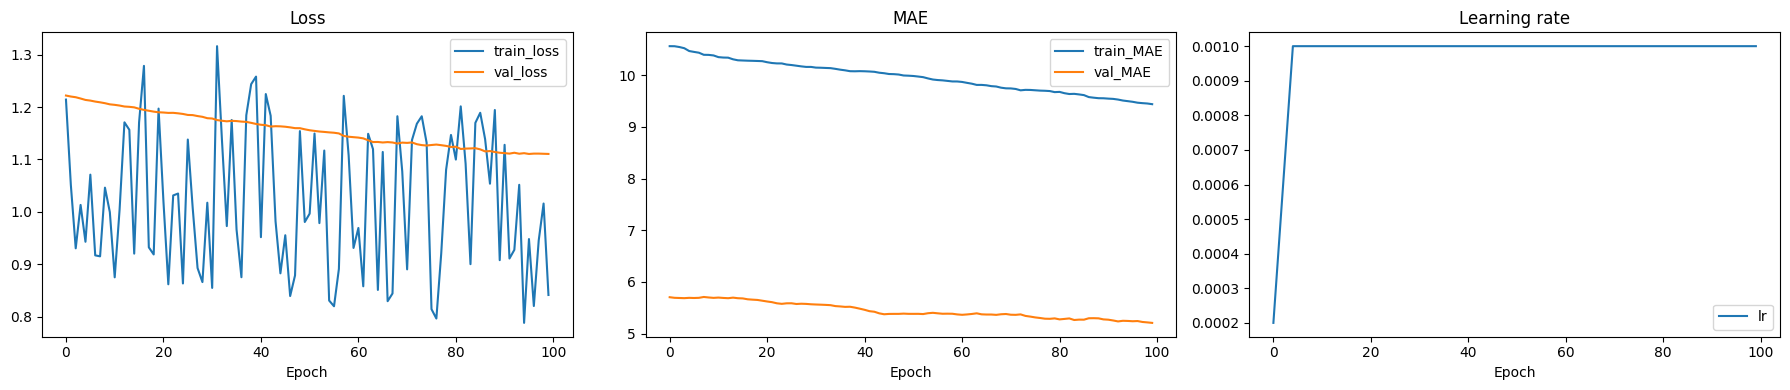

In [768]:
plot_history(small_history, metric_name="MAE")

medium

Epoch 001 | lr=0.000200 | train_loss=1.191651 | val_loss=1.095418 | train_metric=10.813446 | val_metric=5.197493
Epoch 002 | lr=0.000400 | train_loss=0.939564 | val_loss=1.092428 | train_metric=10.805296 | val_metric=5.191506
Epoch 003 | lr=0.000600 | train_loss=1.240970 | val_loss=1.093860 | train_metric=10.808060 | val_metric=5.190160
Epoch 004 | lr=0.000800 | train_loss=1.207880 | val_loss=1.091889 | train_metric=10.800793 | val_metric=5.177222
Epoch 005 | lr=0.001000 | train_loss=1.223375 | val_loss=1.088574 | train_metric=10.785042 | val_metric=5.153523
Epoch 006 | lr=0.001000 | train_loss=1.196586 | val_loss=1.086001 | train_metric=10.772212 | val_metric=5.149839
Epoch 007 | lr=0.001000 | train_loss=0.966083 | val_loss=1.086658 | train_metric=10.766278 | val_metric=5.156608
Epoch 008 | lr=0.001000 | train_loss=1.007408 | val_loss=1.085689 | train_metric=10.763379 | val_metric=5.150101
Epoch 009 | lr=0.001000 | train_loss=1.154887 | val_loss=1.083184 | train_metric=10.747806 | val

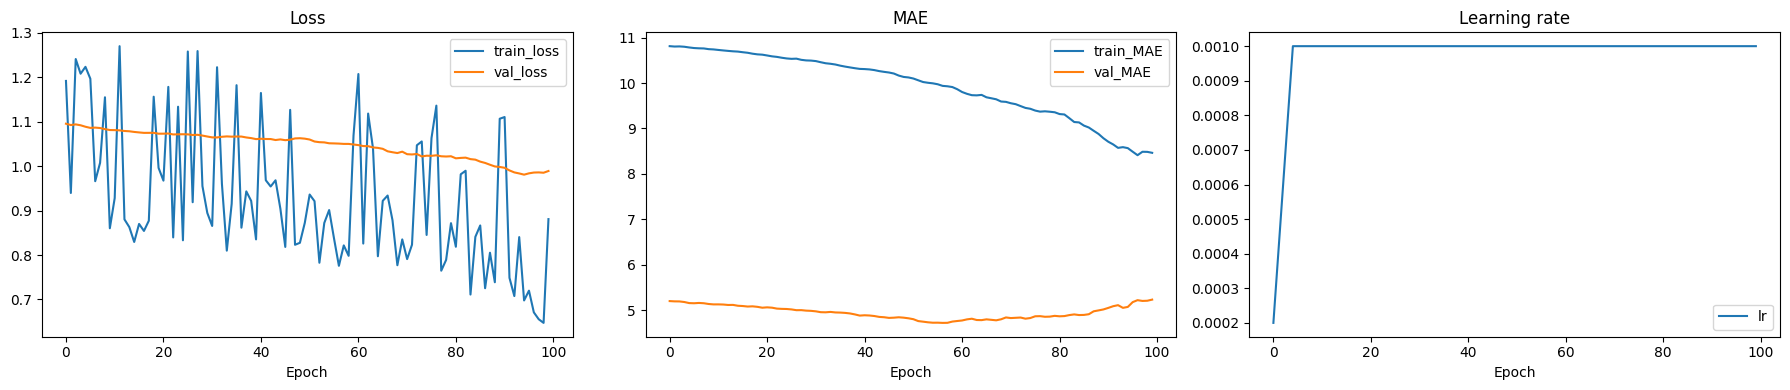

In [769]:
medium_history = train_regression_model(medium_model, optimizer_name="adam", lr=1e-3, epochs=100, batch_size=8)
plot_history(medium_history, metric_name="MAE")

large

Epoch 001 | lr=0.000200 | train_loss=0.908019 | val_loss=1.124665 | train_metric=11.404576 | val_metric=5.643642
Epoch 002 | lr=0.000400 | train_loss=1.119661 | val_loss=1.122851 | train_metric=11.383826 | val_metric=5.610137
Epoch 003 | lr=0.000600 | train_loss=0.912231 | val_loss=1.122680 | train_metric=11.373554 | val_metric=5.606231
Epoch 004 | lr=0.000800 | train_loss=0.962867 | val_loss=1.121536 | train_metric=11.357803 | val_metric=5.588975
Epoch 005 | lr=0.001000 | train_loss=0.957810 | val_loss=1.121036 | train_metric=11.311659 | val_metric=5.543403
Epoch 006 | lr=0.001000 | train_loss=0.917183 | val_loss=1.119156 | train_metric=11.273631 | val_metric=5.498400
Epoch 007 | lr=0.001000 | train_loss=1.048632 | val_loss=1.118532 | train_metric=11.243007 | val_metric=5.462774
Epoch 008 | lr=0.001000 | train_loss=0.875277 | val_loss=1.116805 | train_metric=11.212612 | val_metric=5.448358
Epoch 009 | lr=0.001000 | train_loss=0.904381 | val_loss=1.116086 | train_metric=11.207857 | val

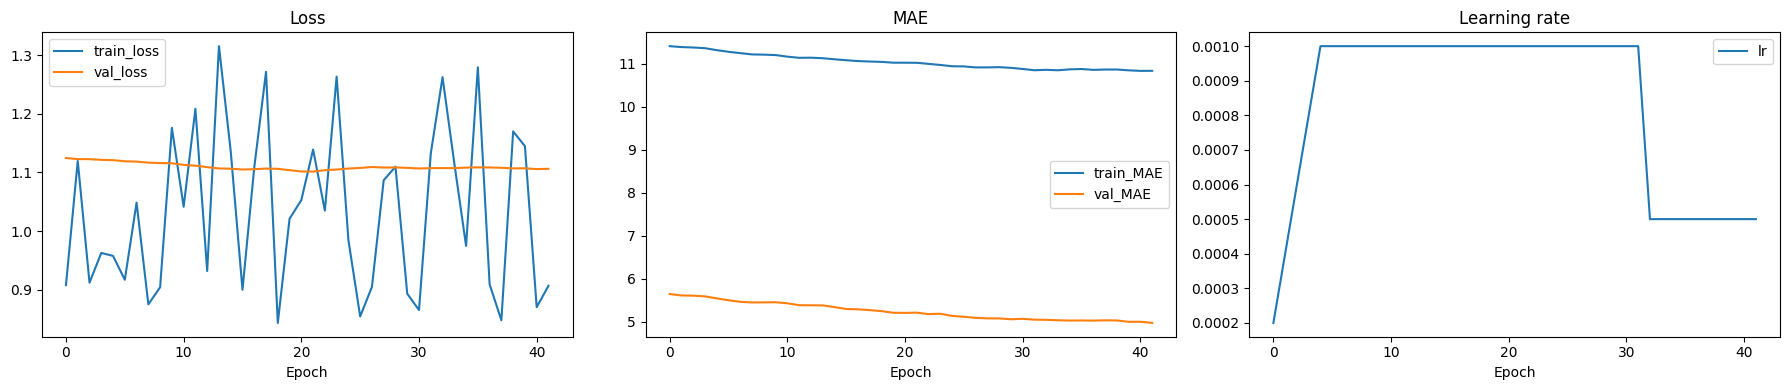

In [770]:
large_history = train_regression_model(large_model, optimizer_name="adam", lr=1e-3, epochs=100, batch_size=8)
plot_history(large_history, metric_name="MAE")

### Оценка на тесте

In [771]:
def evaluate_regression_test(model, name="model"):
    test_loss, test_preds_scaled, test_targets_scaled = evaluate_model(model, loss_fn_reg, X_test, y_test, batch_size=8)

    test_preds = inverse_transform_targets(test_preds_scaled)
    test_targets = inverse_transform_targets(test_targets_scaled)

    test_mae = mae_metric(test_targets, test_preds)
    test_r2 = r2_metric(test_targets, test_preds)

    print(f"{name}:")
    print(f"  test_loss (scaled MSE) = {test_loss:.6f}")
    print(f"  test_MAE = {test_mae:.6f}")
    print(f"  test_R2 = {test_r2:.6f}")

    return {
        "name": name,
        "test_loss": test_loss,
        "test_mae": test_mae,
        "test_r2": test_r2
    }

In [772]:
small_result = evaluate_regression_test(small_model, "Small FCNN")
medium_result = evaluate_regression_test(medium_model, "Medium FCNN")
large_result = evaluate_regression_test(large_model, "Large FCNN")

Small FCNN:
  test_loss (scaled MSE) = 0.474777
  test_MAE = 8.190842
  test_R2 = -0.345450
Medium FCNN:
  test_loss (scaled MSE) = 0.541670
  test_MAE = 8.595542
  test_R2 = -0.502493
Large FCNN:
  test_loss (scaled MSE) = 0.448966
  test_MAE = 6.974353
  test_R2 = -0.007683


### Сравнение

In [773]:
regression_results = [small_result, medium_result, large_result]

for res in regression_results:
    print(res)

{'name': 'Small FCNN', 'test_loss': np.float64(0.47477741812283064), 'test_mae': np.float64(8.190841864359614), 'test_r2': np.float64(-0.34545028005063294)}
{'name': 'Medium FCNN', 'test_loss': np.float64(0.5416704264310893), 'test_mae': np.float64(8.59554155200889), 'test_r2': np.float64(-0.5024929075050062)}
{'name': 'Large FCNN', 'test_loss': np.float64(0.44896633491393856), 'test_mae': np.float64(6.974353079786655), 'test_r2': np.float64(-0.007682579057538774)}


In [774]:
activation_names = ["relu", "elu", "gelu"]
activation_results = []

for act_name in activation_names:
    print(f"\nTraining medium model with activation = {act_name}")

    model = build_regression_fcnn(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden_dims=[32, 16],
        activation=act_name,
        dropout_p=0.2,
        use_bn=True
    )

    history = train_regression_model(model, optimizer_name="adam", lr=1e-3, epochs=80, batch_size=8)
    result = evaluate_regression_test(model, f"Medium FCNN ({act_name})")

    activation_results.append((act_name, history, result))


Training medium model with activation = relu
Epoch 001 | lr=0.000200 | train_loss=1.277934 | val_loss=1.173420 | train_metric=10.842002 | val_metric=5.202947
Epoch 002 | lr=0.000400 | train_loss=1.046804 | val_loss=1.171907 | train_metric=10.822963 | val_metric=5.202598
Epoch 003 | lr=0.000600 | train_loss=1.021000 | val_loss=1.170612 | train_metric=10.807155 | val_metric=5.202949
Epoch 004 | lr=0.000800 | train_loss=0.861109 | val_loss=1.169822 | train_metric=10.782702 | val_metric=5.197129
Epoch 005 | lr=0.001000 | train_loss=1.167193 | val_loss=1.168332 | train_metric=10.755739 | val_metric=5.192218
Epoch 006 | lr=0.001000 | train_loss=1.006911 | val_loss=1.166854 | train_metric=10.726889 | val_metric=5.183104
Epoch 007 | lr=0.001000 | train_loss=0.910452 | val_loss=1.165328 | train_metric=10.710281 | val_metric=5.175067
Epoch 008 | lr=0.001000 | train_loss=0.867607 | val_loss=1.163680 | train_metric=10.683490 | val_metric=5.166938
Epoch 009 | lr=0.001000 | train_loss=0.988183 | va

# Мультиклассификация (MNIST)

классификация изображений рукописных цифр из датасета MNIST


для решения задачи используется сверточная нейронная сеть (CNN), так как:
- изображения имеют пространственную структуру
- свёртки позволяют извлекать локальные признаки (контуры, формы)
- CNN значительно эффективнее FCNN на изображениях

В модели используются:
- Conv2d — для извлечения признаков
- MaxPool2d — для уменьшения размерности
- Flatten — переход к полносвязной части
- Linear — классификация
- LogSoftMax + NLL — функция потерь

In [775]:
import torch
from torchvision import datasets, transforms

In [776]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

### Тут импортировали данные, но нам надо переделать всё в numpy

In [777]:
def dataset_to_numpy(dataset):
    X = []
    y = []

    for img, label in dataset:
        X.append(img.numpy())
        y.append(label)

    X = np.stack(X).astype(np.float32)
    y = np.array(y)

    return X, y

### Очереденая машинка

In [778]:
X_train, y_train = dataset_to_numpy(train_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)

print(X_train.shape)  # (60000, 1, 28, 28)
print(y_train.shape)

(60000, 1, 28, 28)
(60000,)


In [779]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

## One-hot encoding

In [780]:
def one_hot(labels, num_classes=10):
    y = np.zeros((labels.shape[0], num_classes), dtype=np.float32)
    y[np.arange(labels.shape[0]), labels] = 1.0
    return y

In [781]:
y_train_oh = one_hot(y_train, 10)
y_val_oh = one_hot(y_val, 10)
y_test_oh = one_hot(y_test, 10)

### acuracy

In [782]:
def accuracy_metric(y_true, y_pred):
    pred_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    return np.mean(pred_labels == true_labels)

## CNN

## Модель слишком долго обучается, так что уменьшим размер датасета

In [783]:
np.random.seed(42)

train_subset = 16000
val_subset = 4000
test_subset = 4000

train_idx = np.random.choice(len(X_train), train_subset, replace=False)
val_idx = np.random.choice(len(X_val), val_subset, replace=False)
test_idx = np.random.choice(len(X_test), test_subset, replace=False)

X_train_small = X_train[train_idx]
y_train_small = y_train_oh[train_idx]

X_val_small = X_val[val_idx]
y_val_small = y_val_oh[val_idx]

X_test_small = X_test[test_idx]
y_test_small = y_test_oh[test_idx]

print(X_train_small.shape, y_train_small.shape)
print(X_val_small.shape, y_val_small.shape)
print(X_test_small.shape, y_test_small.shape)

(16000, 1, 28, 28) (16000, 10)
(4000, 1, 28, 28) (4000, 10)
(4000, 1, 28, 28) (4000, 10)


In [784]:
def build_mnist_cnn_fast():
    model = Sequential()

    model.add(Conv2d(1, 4, kernel_size=3, stride=1, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(4, 8, kernel_size=3, stride=1, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten(start_dim=1))

    model.add(Linear(8 * 7 * 7, 32))
    model.add(ReLU())
    model.add(Linear(32, 10))
    model.add(LogSoftMax())

    return model

## Архитектура CNN

Модель состоит из двух сверточных блоков и полносвязной части

### Сверточная часть:
Каждый блок:
\[
Conv2d \rightarrow BatchNorm \rightarrow ReLU \rightarrow MaxPool
\]


После двух блоков размер изображения уменьшается:
\[
28×28 \rightarrow 14×14 \rightarrow 7×7
\]

### Полносвязная часть:
\[
Flatten \rightarrow Linear \rightarrow ReLU \rightarrow Dropout \rightarrow Linear
\]

В конце используется:
\[
LogSoftMax
\]


In [785]:
loss_fn_cls = ClassNLLCriterion()

### обучение

In [ ]:
def train_mnist_model():
    model = build_mnist_cnn_fast()

    optimizer = make_optimizer("adam", model, lr=1e-3)

    warmup = WarmupScheduler(optimizer, base_lr=1e-3, warmup_epochs=3)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=3)
    early_stopping = EarlyStopping(patience=5, mode="min")

    history = fit(
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn_cls,
        X_train=X_train_small,
        y_train=y_train_small,
        X_val=X_val_small,
        y_val=y_val_small,
        epochs=15,
        batch_size=128,
        metric_fn=accuracy_metric,
        scheduler=scheduler,
        warmup=warmup,
        early_stopping=early_stopping,
        verbose=True
    )

    return model, history

In [787]:
mnist_model, mnist_history = train_mnist_model()

Epoch 001 | lr=0.000333 | train_loss=2.038268 | val_loss=1.552744 | train_metric=0.557000 | val_metric=0.554250
Epoch 002 | lr=0.000667 | train_loss=0.752195 | val_loss=0.458683 | train_metric=0.862688 | val_metric=0.863250
Epoch 003 | lr=0.001000 | train_loss=0.358716 | val_loss=0.296704 | train_metric=0.910563 | val_metric=0.908500
Epoch 004 | lr=0.001000 | train_loss=0.265113 | val_loss=0.238761 | train_metric=0.929188 | val_metric=0.925750
Epoch 005 | lr=0.001000 | train_loss=0.222389 | val_loss=0.197679 | train_metric=0.942375 | val_metric=0.939500
Epoch 006 | lr=0.001000 | train_loss=0.183532 | val_loss=0.170921 | train_metric=0.950250 | val_metric=0.945500
Epoch 007 | lr=0.001000 | train_loss=0.159429 | val_loss=0.154182 | train_metric=0.957313 | val_metric=0.952750
Epoch 008 | lr=0.001000 | train_loss=0.139814 | val_loss=0.132365 | train_metric=0.963500 | val_metric=0.955500
Epoch 009 | lr=0.001000 | train_loss=0.125314 | val_loss=0.124708 | train_metric=0.966250 | val_metric=0

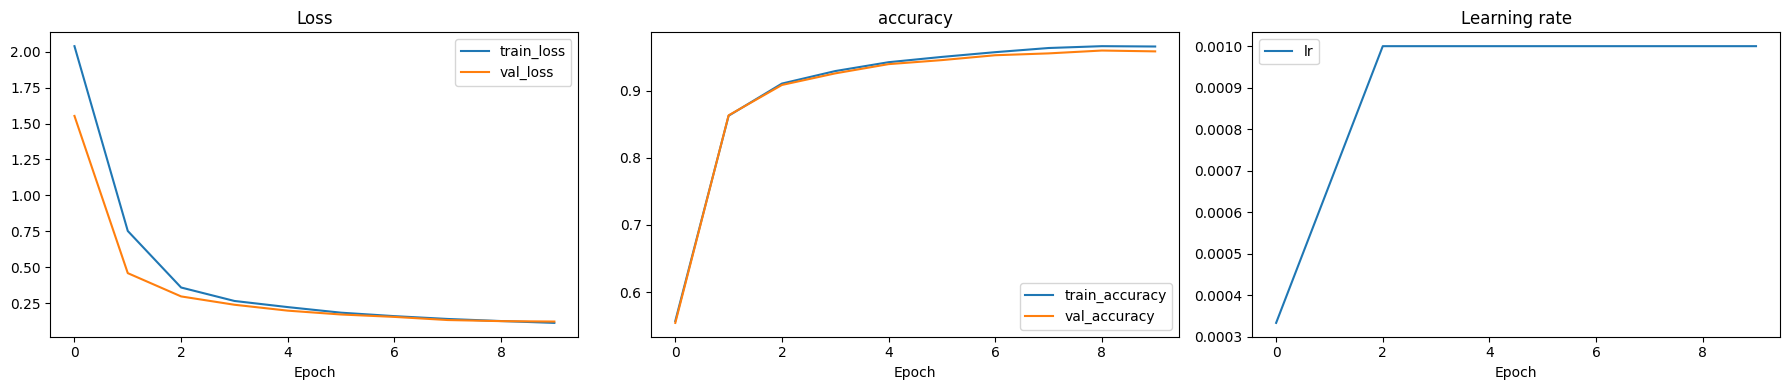

In [788]:
plot_history(mnist_history, metric_name="accuracy")

In [789]:
test_loss, test_preds, test_targets = evaluate_model(
    mnist_model,
    loss_fn_cls,
    X_test,
    y_test_oh,
    batch_size=128
)

test_acc = accuracy_metric(test_targets, test_preds)

print("Test accuracy:", test_acc)

Test accuracy: 0.9636


## результаты классификации

Модель показала высокую точность на тестовой выборке MNIST

Использование сверточной архитектуры позволило эффективно извлекать признаки из изображений, уменьшить количество параметров по сравнению с FCNN и добиться высокой точности

# Автоэнкодер

В качестве третьей модели я реализовал автоэнкодер для изображений MNIST


в этой работе я реализовал автоэнкодер, который использует:
- сверточные слои
- полносвязные слои
- batch normalization
- dropout

In [790]:
class Sigmoid(Module):
    def __init__(self):
        super(Sigmoid, self).__init__()

    def updateOutput(self, input):
        self.output = 1.0 / (1.0 + np.exp(-input))
        return self.output

    def updateGradInput(self, input, gradOutput):
        sig = self.output
        self.gradInput = gradOutput * sig * (1.0 - sig)
        return self.gradInput

    def __repr__(self):
        return "Sigmoid"

In [791]:
np.random.seed(42)

ae_train_subset = 10000
ae_val_subset = 2000
ae_test_subset = 2000

ae_train_idx = np.random.choice(len(X_train), ae_train_subset, replace=False)
ae_val_idx = np.random.choice(len(X_val), ae_val_subset, replace=False)
ae_test_idx = np.random.choice(len(X_test), ae_test_subset, replace=False)

X_train_ae = X_train[ae_train_idx]
X_val_ae = X_val[ae_val_idx]
X_test_ae = X_test[ae_test_idx]

print(X_train_ae.shape, X_val_ae.shape, X_test_ae.shape)

(10000, 1, 28, 28) (2000, 1, 28, 28) (2000, 1, 28, 28)


In [792]:
def build_autoencoder(latent_dim=32):
    model = Sequential()

    # Encoder
    model.add(Conv2d(1, 4, kernel_size=3, stride=1, padding=1))
    model.add(BatchNormalization(alpha=0.9))
    model.add(ChannelwiseScaling(4))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(4, 8, kernel_size=3, stride=1, padding=1))
    model.add(BatchNormalization(alpha=0.9))
    model.add(ChannelwiseScaling(8))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten(start_dim=1))

    # Bottleneck
    model.add(Linear(8 * 7 * 7, 64))
    model.add(ReLU())
    model.add(Dropout(0.2))
    model.add(Linear(64, latent_dim))
    model.add(ReLU())

    # Decoder
    model.add(Linear(latent_dim, 64))
    model.add(ReLU())
    model.add(Dropout(0.2))
    model.add(Linear(64, 28 * 28))
    model.add(Sigmoid())

    return model

### подготовка таргета 

In [793]:
def flatten_images(X):
    return X.reshape(X.shape[0], -1).astype(np.float32)

In [794]:
y_train_ae = flatten_images(X_train_ae)
y_val_ae = flatten_images(X_val_ae)
y_test_ae = flatten_images(X_test_ae)

In [795]:
def reconstruction_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

### Обучение автоэнкодера

In [796]:
loss_fn_ae = MSECriterion()

In [797]:
def train_autoencoder(latent_dim=32):
    model = build_autoencoder(latent_dim=latent_dim)

    optimizer = make_optimizer("adam", model, lr=1e-3)

    warmup = WarmupScheduler(optimizer, base_lr=1e-3, warmup_epochs=2)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, mode="min")

    history = fit(
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn_ae,
        X_train=X_train_ae,
        y_train=y_train_ae,
        X_val=X_val_ae,
        y_val=y_val_ae,
        epochs=15,
        batch_size=256,
        metric_fn=reconstruction_mae,
        scheduler=scheduler,
        warmup=warmup,
        early_stopping=early_stopping,
        verbose=True
    )

    return model, history

In [798]:
ae_model, ae_history = train_autoencoder(latent_dim=32)

Epoch 001 | lr=0.000500 | train_loss=0.196104 | val_loss=0.109017 | train_metric=0.276076 | val_metric=0.275906
Epoch 002 | lr=0.001000 | train_loss=0.079880 | val_loss=0.066848 | train_metric=0.169632 | val_metric=0.168990
Epoch 003 | lr=0.001000 | train_loss=0.069355 | val_loss=0.065460 | train_metric=0.153634 | val_metric=0.152982
Epoch 004 | lr=0.001000 | train_loss=0.067821 | val_loss=0.064814 | train_metric=0.151583 | val_metric=0.150926
Epoch 005 | lr=0.001000 | train_loss=0.066799 | val_loss=0.064278 | train_metric=0.147959 | val_metric=0.147300
Epoch 006 | lr=0.001000 | train_loss=0.065700 | val_loss=0.063622 | train_metric=0.145968 | val_metric=0.145347
Epoch 007 | lr=0.001000 | train_loss=0.064535 | val_loss=0.062573 | train_metric=0.141426 | val_metric=0.140914
Epoch 008 | lr=0.001000 | train_loss=0.063017 | val_loss=0.061068 | train_metric=0.135506 | val_metric=0.135120
Epoch 009 | lr=0.001000 | train_loss=0.061886 | val_loss=0.059629 | train_metric=0.133424 | val_metric=0

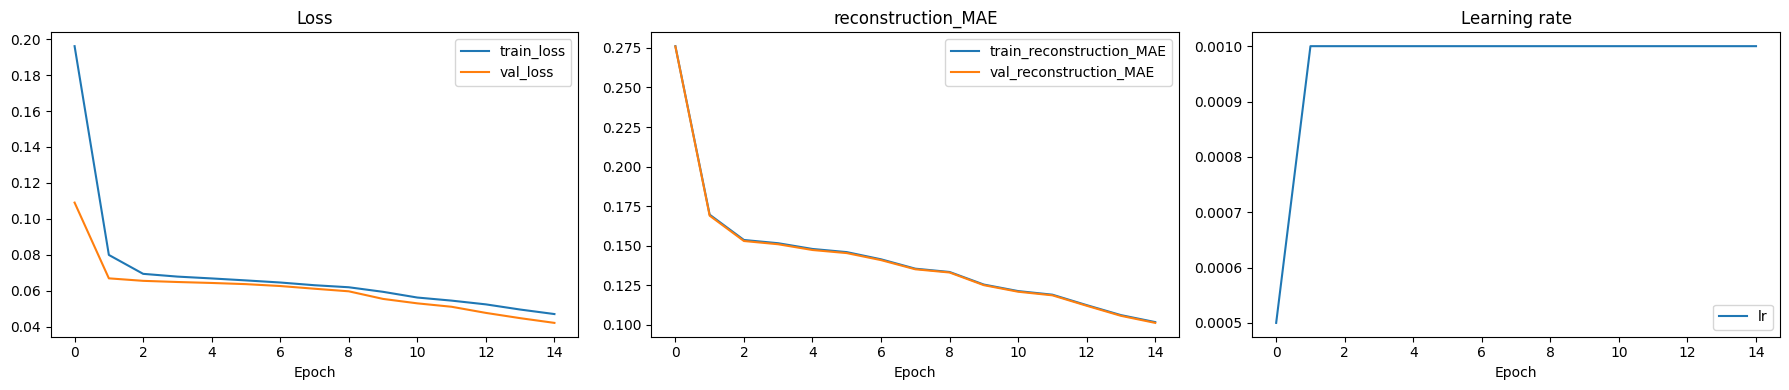

In [799]:
plot_history(ae_history, metric_name="reconstruction_MAE")

### Оценка на тесте

In [800]:
ae_test_loss, ae_test_preds, ae_test_targets = evaluate_model(
    ae_model,
    loss_fn_ae,
    X_test_ae,
    y_test_ae,
    batch_size=128
)

ae_test_mae = reconstruction_mae(ae_test_targets, ae_test_preds)

print("Autoencoder test loss (MSE):", ae_test_loss)
print("Autoencoder test MAE:", ae_test_mae)

Autoencoder test loss (MSE): 0.04212537263520546
Autoencoder test MAE: 0.10180844254341115


### визуализация реконструкций 

In [801]:
def show_reconstructions(model, X, n=8):
    model.evaluate()

    X_sample = X[:n]
    recon = model.forward(X_sample).reshape(n, 28, 28)

    original = X_sample.reshape(n, 28, 28)

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))

    for i in range(n):
        axes[0, i].imshow(original[i], cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")

        axes[1, i].imshow(recon[i], cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("Recon")

    plt.tight_layout()
    plt.show()

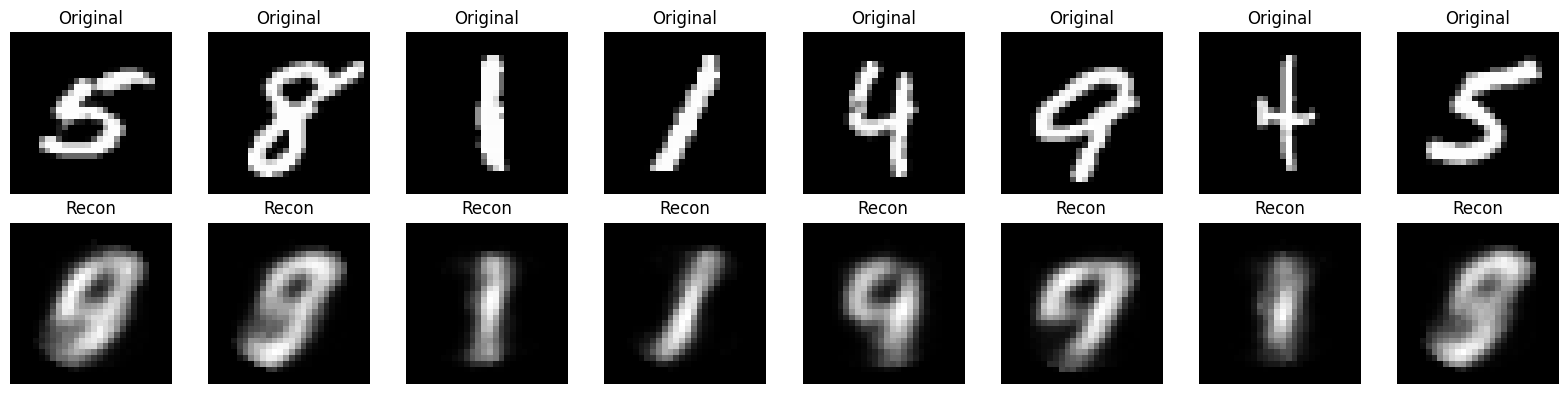

In [802]:
show_reconstructions(ae_model, X_test_ae, n=8)

## вывод

в целом, автоэнкодер обучился восстанавливать изображения MNIST,  
Использование сверточной части в encoder позволило эффективно выделять пространственные признаки, а полносвязный bottleneck дал компактное латентное представление объекта

в силу недостаточных ресурсов получился этакий кринж, но модель обучалась на урезанных данных (15-20% от общего датасета) и, как я думаю, показала достойный результат 

Качество работы автоэнкодера оценивалось:
- численно — через MSE и MAE
- визуально — через сравнение исходных и восстановленных изображений